#CODE APPENDIX FOR ASTR 5540 HW 2

##"Good function" $Q(x)=\sin\left(\frac{\pi x}{L}\right)$

Hi! How complex should we make our matrix: (choose a positive integer N): 100
Great! Now what should the length of our domain be (choose a positive L): 10


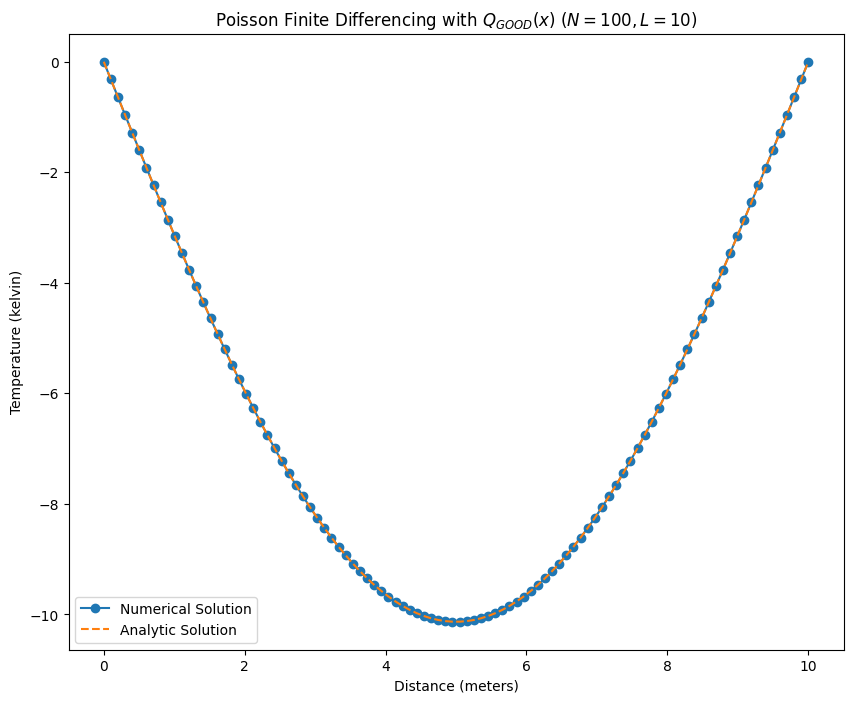

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#Select value of n and L
N_input = input("Hi! How complex should we make our matrix: (choose a positive integer N): ")
N = int(N_input)

L_input = input("Great! Now what should the length of our domain be (choose a positive L): ")
L = int(L_input)



#Make tridiagonal matrix M
M = np.zeros((N, N))
M[0, 0] = 1
M[N-1, N-1] = 1
for i in range(1, N-1):
    M[i, i-1] = 1
    M[i, i] = -2
    M[i, i+1] = 1


# Define our good function Q_good
def Q_good(x):
    return np.sin(np.pi * x / L)

#Define the analytical solution
def Q_good_analytical(x):
  return -(L**2/np.pi**2) * np.sin(np.pi * x / L)

#Create the constant vector b=\Delta^2\tilde{M}
delta = L / (N-1)
b = np.zeros(N)
for i in range(1,N-1):
  b[i] = delta**2 * Q_good(i*delta)
b[0] = 0
b[-1] = 0

# solve the linear equations
y = np.linalg.solve(M, b)


x = np.linspace(0, L, N)

plt.figure(figsize=(10,8))
plt.plot(x, y, 'o-', label='Numerical Solution')
plt.plot(x, Q_good_analytical(x), '--', label='Analytic Solution')
plt.xlabel(r'Distance (meters)')
plt.ylabel('Temperature (kelvin)')
plt.title(f'Poisson Finite Differencing with $Q_{{GOOD}}(x)$ $(N={N}, L={L})$')
plt.legend()
plt.show()


##"Bad function"  $Q(x)=e^{x/L}\sin\left(\frac{\pi x}{L}\right)$

Hi! How complex should we make our matrix: (choose a positive integer N): 100
Great! Now what should the length of our domain be (choose a positive L): 10


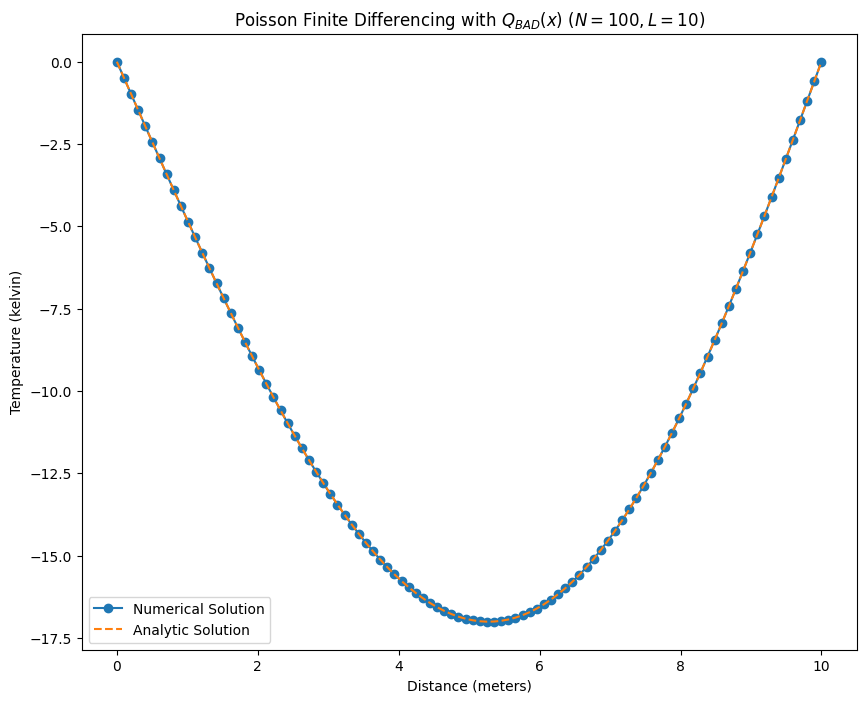

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#Select value of n and L
N_input = input("Hi! How complex should we make our matrix: (choose a positive integer N): ")
N = int(N_input)

L_input = input("Great! Now what should the length of our domain be (choose a positive L): ")
L = int(L_input)



#Make tridiagonal matrix M
M = np.zeros((N, N))
M[0, 0] = 1
M[N-1, N-1] = 1
for i in range(1, N-1):
    M[i, i-1] = 1
    M[i, i] = -2
    M[i, i+1] = 1


# Define our good function Q_good
def Q_bad(x):
    return np.exp(x/L) * np.sin(np.pi * x / L)

#Define the analytical solution
def Q_bad_analytical(x):
  trig_terms = (((1 - np.pi**2) * np.sin(np.pi * x / L)) - 2 * np.pi * np.cos(np.pi * x / L))
  c_1 = (-2 * np.pi * (np.e + 1) * L)/(np.pi**2 + 1)**2
  c_2 = (2 * np.pi * L**2)/(np.pi**2 + 1)**2
  return (L**2 * np.exp(x/L))/(np.pi**2 + 1 )**2 *  trig_terms + c_1 * x + c_2


#Create the constant vector b=\Delta^2\tilde{M}
delta = L / (N-1)
b = np.zeros(N)
for i in range(1,N-1):
  b[i] = delta**2 * Q_bad(i*delta)
b[0] = 0
b[-1] = 0

# solve the linear equations
y = np.linalg.solve(M, b)


x = np.linspace(0, L, N)

plt.figure(figsize=(10,8))
plt.plot(x, y, 'o-', label='Numerical Solution')
plt.plot(x, Q_bad_analytical(x), '--', label='Analytic Solution')
plt.xlabel(r'Distance (meters)')
plt.ylabel('Temperature (kelvin)')
plt.title(f'Poisson Finite Differencing with $Q_{{BAD}}(x)$ $(N={N}, L={L})$')
plt.legend()
plt.show()


##"Ugly function"  $Q(x)=\cos\left(\frac{4\pi x}{L}\right)$

Hi! How complex should we make our matrix: (choose a positive integer N): 100
Great! Now what should the length of our domain be (choose a positive L): 10


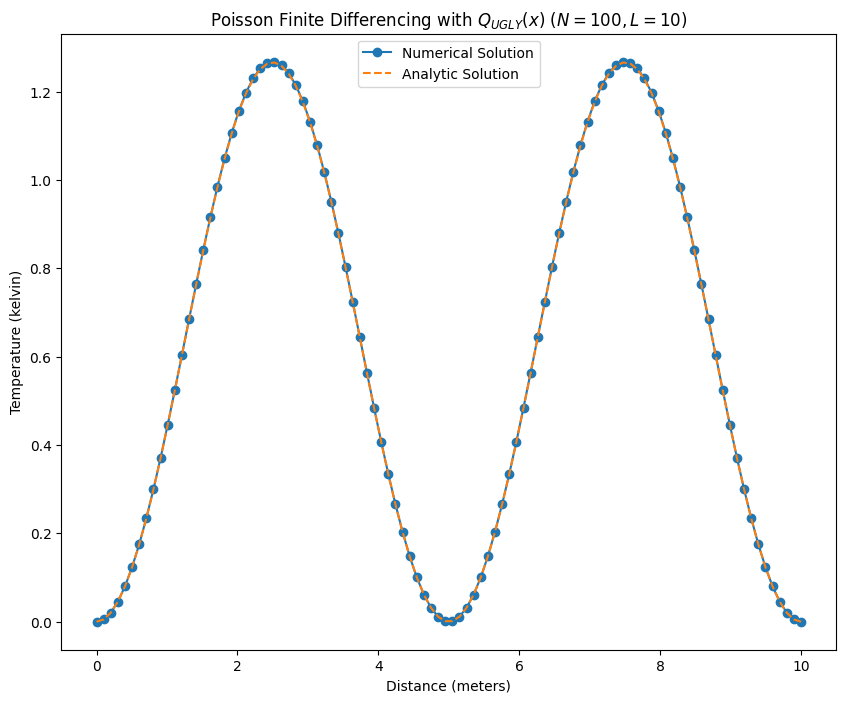

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#Select value of n and L
N_input = input("Hi! How complex should we make our matrix: (choose a positive integer N): ")
N = int(N_input)

L_input = input("Great! Now what should the length of our domain be (choose a positive L): ")
L = int(L_input)



#Make tridiagonal matrix M
M = np.zeros((N, N))
M[0, 0] = 1
M[N-1, N-1] = 1
for i in range(1, N-1):
    M[i, i-1] = 1
    M[i, i] = -2
    M[i, i+1] = 1


# Define our ugly function Q_ugly
def Q_ugly(x):
    return np.cos(4 * np.pi * x / L)

#Define the analytical solution
def Q_ugly_analytical(x):
  c_2 = (L**2)/(16 * np.pi**2)
  return c_2 * (1 - np.cos(4 * np.pi * x / L))


#Create the constant vector b=\Delta^2\tilde{M}
delta = L / (N-1)
b = np.zeros(N)
for i in range(1,N-1):
  b[i] = delta**2 * Q_ugly(i*delta)
b[0] = 0
b[-1] = 0

# solve the linear equations
y = np.linalg.solve(M, b)


x = np.linspace(0, L, N)

plt.figure(figsize=(10,8))
plt.plot(x, y, 'o-', label='Numerical Solution')
plt.plot(x, Q_ugly_analytical(x), '--', label='Analytic Solution')
plt.xlabel(r'Distance (meters)')
plt.ylabel('Temperature (kelvin)')
plt.title(f'Poisson Finite Differencing with $Q_{{UGLY}}(x)$ $(N={N}, L={L})$')
plt.legend()
plt.show()


## Resolution study for $Q_{BAD}$

Plot of varied $N$ values

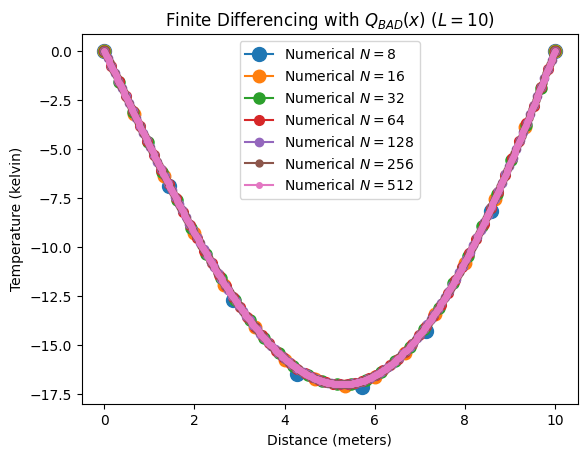

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


N_values = [8, 16, 32, 64, 128, 256, 512]
L = 10


# Define our bad function Q_bad
def Q_bad(x):
    return np.exp(x/L) * np.sin(np.pi * x / L)

#Define the analytical solution
def Q_bad_analytical(x):
  trig_terms = (((1 - np.pi**2) * np.sin(np.pi * x / L)) - 2 * np.pi * np.cos(np.pi * x / L))
  c_1 = (-2 * np.pi * (np.e + 1) * L)/(np.pi**2 + 1)**2
  c_2 = (2 * np.pi * L**2)/(np.pi**2 + 1)**2
  return (L**2 * np.exp(x/L))/(np.pi**2 + 1 )**2 *  trig_terms + c_1 * x + c_2

for n_val_idx in range(len(N_values)):
  current_N = N_values[n_val_idx] # Get the current N value

  #Make tridiagonal matrix M
  M = np.zeros((current_N, current_N))
  M[0, 0] = 1
  M[current_N-1, current_N-1] = 1
  for j in range(1, current_N-1):
      M[j, j-1] = 1
      M[j, j] = -2
      M[j, j+1] = 1


  #Create the constant vector b=\Delta^2\tilde{M}
  delta = L / (current_N-1)
  b = np.zeros(current_N)
  for k in range(1,current_N-1):
    b[k] = delta**2 * Q_bad(k*delta)
  b[0] = 0
  b[-1] = 0

  # solve the linear equations
  y = np.linalg.solve(M, b)


  x = np.linspace(0, L, current_N)


  plt.plot(x, y, 'o-', label=f'Numerical $N={current_N}$', markersize=(10-n_val_idx))

# Labels/legend/show happen ONCE, after the loop
plt.xlabel('Distance (meters)')
plt.ylabel('Temperature (kelvin)')
plt.title(f'Finite Differencing with $Q_{{BAD}}(x)$ ($L={L}$)')
plt.legend()
plt.show()

Plot of $\text{Var}(N)$

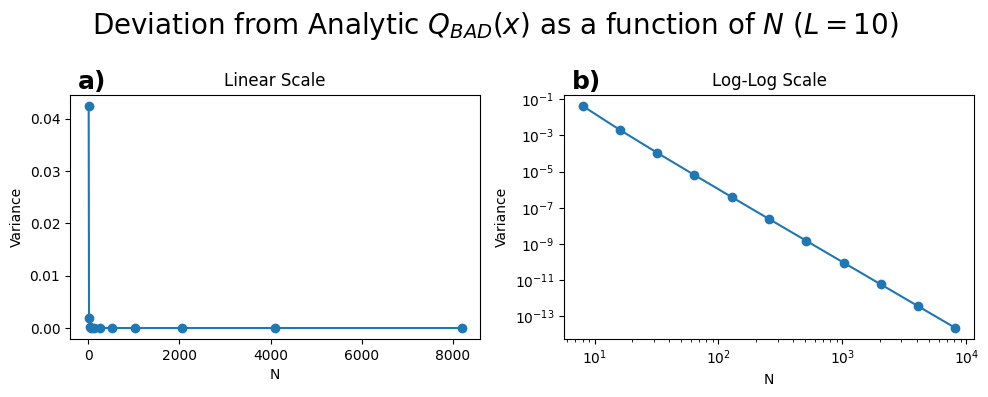

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


N_values = [8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192]
L = 10
residual_variance = []


# Define our bad function Q_bad
def Q_bad(x):
    return np.exp(x/L) * np.sin(np.pi * x / L)

#Define the analytical solution
def Q_bad_analytical(x):
  trig_terms = (((1 - np.pi**2) * np.sin(np.pi * x / L)) - 2 * np.pi * np.cos(np.pi * x / L))
  c_1 = (-2 * np.pi * (np.e + 1) * L)/(np.pi**2 + 1)**2
  c_2 = (2 * np.pi * L**2)/(np.pi**2 + 1)**2
  return (L**2 * np.exp(x/L))/(np.pi**2 + 1 )**2 *  trig_terms + c_1 * x + c_2

for n_val_idx in range(len(N_values)):
  current_N = N_values[n_val_idx] # Get the current N value

  #Make tridiagonal matrix M
  M = np.zeros((current_N, current_N))
  M[0, 0] = 1
  M[current_N-1, current_N-1] = 1
  for j in range(1, current_N-1):
      M[j, j-1] = 1
      M[j, j] = -2
      M[j, j+1] = 1


  #Create the constant vector b=\Delta^2\tilde{M}
  delta = L / (current_N-1)
  b = np.zeros(current_N)
  for k in range(1,current_N-1):
    b[k] = delta**2 * Q_bad(k*delta)
  b[0] = 0
  b[-1] = 0

  # solve the linear equations
  y = np.linalg.solve(M, b)


  x = np.linspace(0, L, current_N)

  #Compute residual variance
  residuals = np.sum((y - Q_bad_analytical(x))**2)
  residual_variance.append(residuals / (current_N - 1))


# Create figure with two side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# ax1: linear scale
ax1.plot(N_values, residual_variance, 'o-')
ax1.set_xlabel('N')
ax1.set_ylabel('Variance')
ax1.set_title(f'Linear Scale')
ax1.text(0.02, 1.1, 'a)', transform=ax1.transAxes, fontsize=18, fontweight='bold', va='top')

# ax2: log-log scale
ax2.loglog(N_values, residual_variance, 'o-')
ax2.set_xlabel('N')
ax2.set_ylabel('Variance')
ax2.set_title(f'Log-Log Scale')
ax2.text(0.02, 1.1, 'b)', transform=ax2.transAxes, fontsize=18, fontweight='bold', va='top')

fig.suptitle(f'Deviation from Analytic $Q_{{BAD}}(x)$ as a function of $N$ ($L=10$)', fontsize=20)
plt.tight_layout()
plt.show()